# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)

print("Imports done")

Imports done


# Load Dataset

In [2]:
rfm       = pd.read_csv('../data/processed/rfm_labeled.csv')
X_encoded = np.load('../data/processed/X_encoded.npy')

print(f"RFM shape     : {rfm.shape}")
print(f"Encoded shape : {X_encoded.shape}")
print(f"Segments      : {rfm['Segment'].unique()}")

RFM shape     : (4338, 6)
Encoded shape : (4338, 2)
Segments      : ['Champions' 'Potential Loyalists' 'At Risk' 'Lost Customers'
 'Loyal Customers']


# Encode Labels

In [3]:
le = LabelEncoder()
y  = le.fit_transform(rfm['Segment'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}  →  {cls}")

with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("\nLabel encoder saved")

Label mapping:
  0  →  At Risk
  1  →  Champions
  2  →  Lost Customers
  3  →  Loyal Customers
  4  →  Potential Loyalists

Label encoder saved


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

Train : 3470 samples
Test  : 868 samples


# Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

with open('../models/classifier_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Random Forest trained")
print("classifier_rf.pkl saved")

Random Forest trained ✓
classifier_rf.pkl saved ✓


In [6]:
# Evaluate
y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}  ({acc*100:.1f}%)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=le.classes_))

Accuracy : 0.9816  (98.2%)

Classification Report:
                     precision    recall  f1-score   support

            At Risk       0.98      0.99      0.99       450
          Champions       1.00      1.00      1.00        15
     Lost Customers       0.99      0.98      0.99       203
    Loyal Customers       1.00      0.93      0.96        41
Potential Loyalists       0.96      0.97      0.97       159

           accuracy                           0.98       868
          macro avg       0.99      0.97      0.98       868
       weighted avg       0.98      0.98      0.98       868



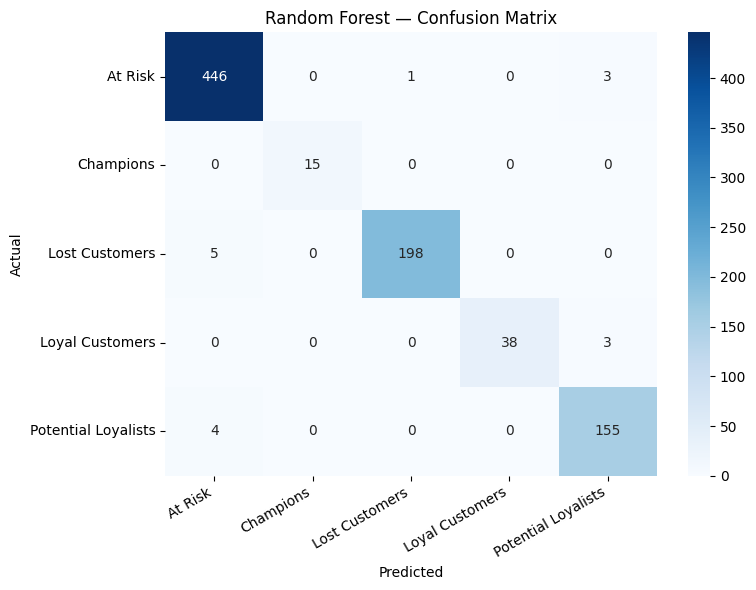

In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

# Cross Validation

In [8]:
cv_scores = cross_val_score(rf, X_encoded, y, cv=5, scoring='accuracy')

print(f"5-Fold Cross Validation Accuracy:")
print(f"  Scores : {cv_scores.round(4)}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}")
print(f"\nStable model = low std deviation")

5-Fold Cross Validation Accuracy:
  Scores : [0.977  0.9816 0.9827 0.985  0.9896]
  Mean   : 0.9832
  Std    : 0.0042

Stable model = low std deviation


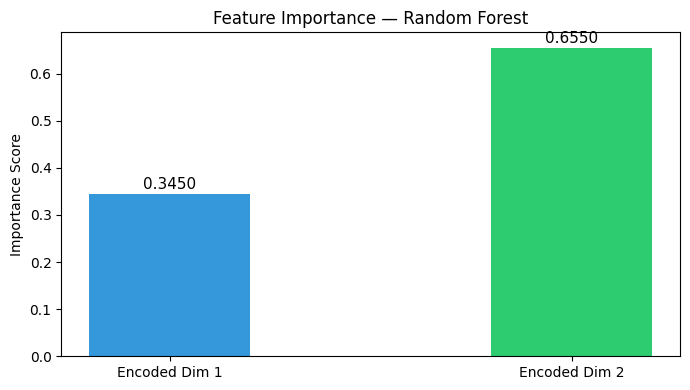

In [9]:
# Feature Importance
importances  = rf.feature_importances_
feature_names = ['Encoded Dim 1', 'Encoded Dim 2']

plt.figure(figsize=(7, 4))
bars = plt.bar(feature_names, importances,
               color=['#3498db', '#2ecc71'], width=0.4)
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
for bar, val in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()